# ViT-Motion — interpretability, quantification & attention-guided fine-tune

Runs the whole research arc in one pass, on your EXISTING trained model (no retrain):
1. Interpretability figures for targets **yaw / dx / norm**.
2. **Sky-vs-ground quantification** of Grad-CAM (turns the observation into a number).
3. **Attention-guided fine-tune** (RobustViT / RRR style) that minimizes sky saliency.
4. Re-evaluate + re-quantify the fine-tuned model to compare.

**Attach as inputs (right panel -> Add Input):**
- your **code** dataset (updated `vit_motion_kaggle.zip` contents),
- your **data** dataset,
- your **artifacts** dataset = unzip `vit_motion_artifacts.zip` and upload it (gives `runs/.../best.pt`, `manifest/`).

**Settings:** GPU = ON, Internet = ON.


In [1]:
# 1) Stage code into a writable dir
import os, sys, glob, shutil, pathlib
CODE_SRC=None
for p in glob.glob('/kaggle/input/**/inspect_dataset.py', recursive=True):
    CODE_SRC=str(pathlib.Path(p).parent); break
assert CODE_SRC, 'Attach the code dataset (must contain inspect_dataset.py).'
WORK='/kaggle/working/vit_motion_project'
if os.path.exists(WORK): shutil.rmtree(WORK)
shutil.copytree(CODE_SRC, WORK); os.chdir(WORK); sys.path.insert(0,WORK)
print('code at', WORK)

code at /kaggle/working/vit_motion_project


In [2]:
# 2) Deps
!pip -q install 'timm>=1.0' 'opencv-python>=4.9' >/dev/null
import torch, timm
print('torch',torch.__version__,'| cuda',torch.cuda.is_available(),'| timm',timm.__version__)

torch 2.10.0+cu128 | cuda True | timm 1.0.26


In [3]:
# 3) Locate data root + checkpoint + (optional) prebuilt manifest
import glob, pathlib, shutil, os
csvs=[c for c in glob.glob('/kaggle/input/**/samples.csv', recursive=True) if not c.startswith(CODE_SRC)]
assert csvs, 'Attach the data dataset.'
DATA_ROOT=sorted({str(pathlib.Path(c).parent.parent) for c in csvs}, key=len)[0]
cks=glob.glob('/kaggle/input/**/best.pt', recursive=True)
assert cks, 'Attach the artifacts dataset containing runs/.../best.pt'
CKPT_SRC=sorted(cks, key=len)[0]
print('DATA_ROOT:',DATA_ROOT); print('checkpoint:',CKPT_SRC)
# reuse the prebuilt manifest/normalization if present (guarantees same scales as training)
os.makedirs('artifacts/manifest', exist_ok=True)
man=glob.glob('/kaggle/input/**/manifest/manifest.csv', recursive=True)
nrm=glob.glob('/kaggle/input/**/manifest/normalization.json', recursive=True)
USE_PREBUILT = bool(man and nrm)
print('prebuilt manifest found:', USE_PREBUILT)

DATA_ROOT: /kaggle/input/notebooks/samantousi/motion-vision/vit-motion-dataset
checkpoint: /kaggle/input/datasets/samantousi/vit-motion-artifacts/runs/vit_motion_temporal_cr_v0_2_1/best.pt
prebuilt manifest found: True


In [4]:
# 4) Manifest: copy prebuilt if available, else rebuild (~5-6 min)
if USE_PREBUILT:
    src=str(pathlib.Path(man[0]).parent)
    for f in ['manifest.csv','normalization.json','splits.json']:
        if os.path.exists(os.path.join(src,f)): shutil.copy(os.path.join(src,f),'artifacts/manifest/'+f)
    print('copied prebuilt manifest from', src)
else:
    get_ipython().system('python inspect_dataset.py --config config_kaggle.yaml --data-root "{DATA_ROOT}"')
# a config whose relative paths resolve inside WORK
import yaml
cfg=yaml.safe_load(open('config_kaggle.yaml')); yaml.safe_dump(cfg,open('config_run.yaml','w'),sort_keys=False,allow_unicode=True)

copied prebuilt manifest from /kaggle/input/datasets/samantousi/vit-motion-artifacts/manifest


In [5]:
# stage the checkpoint into the local runs dir
CKPT='artifacts/runs/vit_motion_temporal_cr_v0_2_1/best.pt'
os.makedirs(os.path.dirname(CKPT), exist_ok=True)
shutil.copy(CKPT_SRC, CKPT)
import pandas as pd
m=pd.read_csv('artifacts/manifest/manifest.csv')
pool=m[m.split=='test'] if (m.split=='test').any() else m
EXP=sorted(pool.experiment_id.astype(str).unique())[0]
print('using experiment:', EXP)

using experiment: 20260804_morning_dry_004


## Step 1 — interpretability for three targets


In [6]:
for tgt in ['yaw','dx','norm']:
    get_ipython().system('python interpret_experiment.py --config config_run.yaml --checkpoint "{CKPT}" --experiment "{EXP}" --num-samples 6 --target '+tgt)

/kaggle/working/vit_motion_project/vit_motion/model.py:64: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(
Explaining 6 window(s) from '20260804_morning_dry_004' (target=yaw)...
  [1/6] saved explain_00_win00000_yaw.png
  [2/6] saved explain_01_win00094_yaw.png
  [3/6] saved explain_02_win00188_yaw.png
  [4/6] saved explain_03_win00283_yaw.png
  [5/6] saved explain_04_win00377_yaw.png
  [6/6] saved explain_05_win00472_yaw.png
Saved interpretability figures to: /kaggle/working/vit_motion_project/artifacts/interpretability/20260804_morning_dry_004
/kaggle/working/vit_motion_project/vit_motion/model.py:64: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(
Explaining 6 window(s) from '20260804_morning_dry_004' (target=dx)...
  [1/6] saved explain_00_wi

## Step 2 — quantify sky vs ground (baseline model)


/kaggle/working/vit_motion_project/vit_motion/model.py:64: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(
  20260804_morning_dry_004: sky-fraction 0.499  (n=40)
  20260805_afternoon_dry_004: sky-fraction 0.513  (n=40)
  20260805_afternoon_dry_017: sky-fraction 0.545  (n=40)
  20260805_afternoon_dry_019: sky-fraction 0.441  (n=40)
  20260805_afternoon_dry_034: sky-fraction 0.507  (n=40)
  20260805_afternoon_dry_037: sky-fraction 0.501  (n=40)

=== SKY vs GROUND saliency ===
{
  "tag": "baseline",
  "target": "yaw",
  "horizon_frac": 0.5,
  "experiments": [
    "20260804_morning_dry_004",
    "20260805_afternoon_dry_004",
    "20260805_afternoon_dry_017",
    "20260805_afternoon_dry_019",
    "20260805_afternoon_dry_034",
    "20260805_afternoon_dry_037"
  ],
  "n_samples": 240,
  "sky_saliency_fraction_mean": 0.5010088017360085,
  "sky_saliency_fraction_std": 0.1750

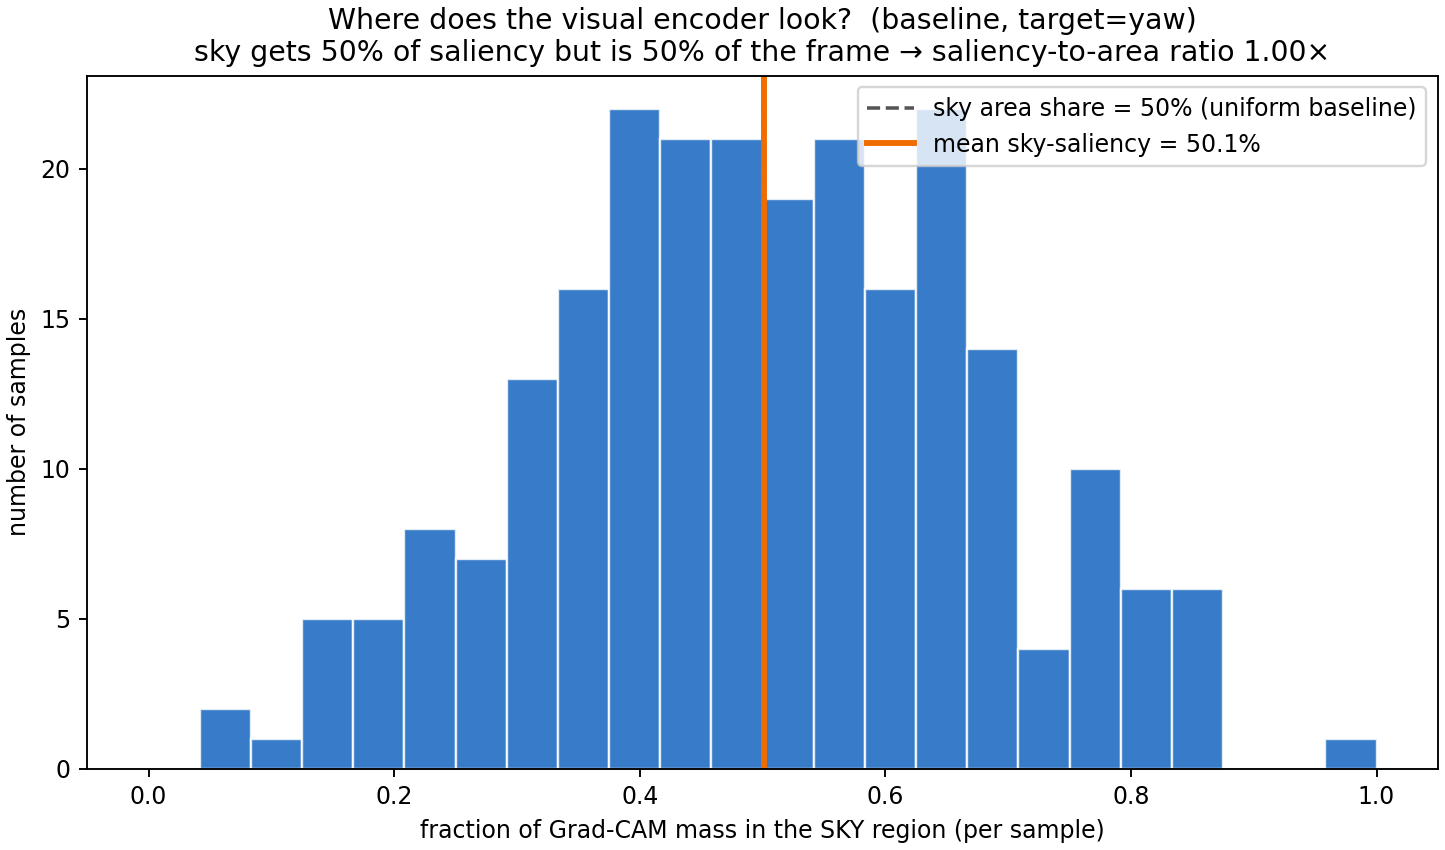

In [7]:
!python interpret_quantify.py --config config_run.yaml --checkpoint "{CKPT}" --experiments auto --max-exp 6 --num-per-exp 40 --target yaw --horizon-frac 0.5 --tag baseline
from IPython.display import Image, display
display(Image('artifacts/quantify/sky_ground_baseline.png'))

## Step 3 — attention-guided fine-tune (minimize sky saliency)

Starts from `best.pt`; a few epochs is enough to see the effect. `--max-steps` caps
steps/epoch for a quick pass; remove it for a full epoch. Double-backprop uses the
math attention kernel, so it is slower than normal training — keep it short.


In [8]:
RRR_CKPT='artifacts/runs/vit_motion_rrr/best_rrr.pt'
!python finetune_rrr.py --config config_run.yaml --checkpoint "{CKPT}" \
    --epochs 3 --lambda-rrr 0.5 --horizon-frac 0.5 --target norm --max-steps 150 \
    --output "{RRR_CKPT}"

/kaggle/working/vit_motion_project/vit_motion/model.py:64: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(
rrr epoch 1:  27%|▎| 150/546 [01:43<04:33,  1.45it/s, sky_frac=0.0421, task=0.03
{"epoch": 1, "task_loss": 0.03487279334415992, "sky_fraction": 0.04212116431755324}
rrr epoch 2:  27%|▎| 150/546 [01:36<04:15,  1.55it/s, sky_frac=0.00616, task=0.0
{"epoch": 2, "task_loss": 0.03515355405708154, "sky_fraction": 0.006158490736658375}
rrr epoch 3:  27%|▎| 150/546 [01:34<04:09,  1.59it/s, sky_frac=0.00311, task=0.0
{"epoch": 3, "task_loss": 0.03405705644438664, "sky_fraction": 0.0031071166096565623}
Saved fine-tuned checkpoint to: /kaggle/working/vit_motion_project/artifacts/runs/vit_motion_rrr/best_rrr.pt


## Step 4 — re-evaluate + re-quantify the fine-tuned model, and compare


In [9]:
!python evaluate_experiment.py --config config_run.yaml --checkpoint "{RRR_CKPT}" --experiment "{EXP}" --output-dir artifacts/evaluation_rrr
!python interpret_quantify.py --config config_run.yaml --checkpoint "{RRR_CKPT}" --experiments auto --max-exp 6 --num-per-exp 40 --target yaw --horizon-frac 0.5 --tag finetuned

/kaggle/working/vit_motion_project/vit_motion/model.py:64: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(
Inference (cuda): 100%|█████████████████████████| 30/30 [00:07<00:00,  3.88it/s]
Saved evaluation to: /kaggle/working/vit_motion_project/artifacts/evaluation_rrr/20260804_morning_dry_004
/kaggle/working/vit_motion_project/vit_motion/model.py:64: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_encoder = nn.TransformerEncoder(
  20260804_morning_dry_004: sky-fraction 0.275  (n=40)
  20260805_afternoon_dry_004: sky-fraction 0.357  (n=38)
  20260805_afternoon_dry_017: sky-fraction 0.316  (n=39)
  20260805_afternoon_dry_019: sky-fraction 0.323  (n=40)
  20260805_afternoon_dry_034: sky-fraction 0.399  (n=38)
  20260805_afternoon_dry_037: sky-fraction 0.307  (n=39)

=== SKY vs GRO

SKY saliency fraction:  baseline 0.501  ->  finetuned 0.329
next_body_dx: finetuned R2=0.865  MAE=0.00950
next_delta_yaw: finetuned R2=0.932  MAE=0.00323


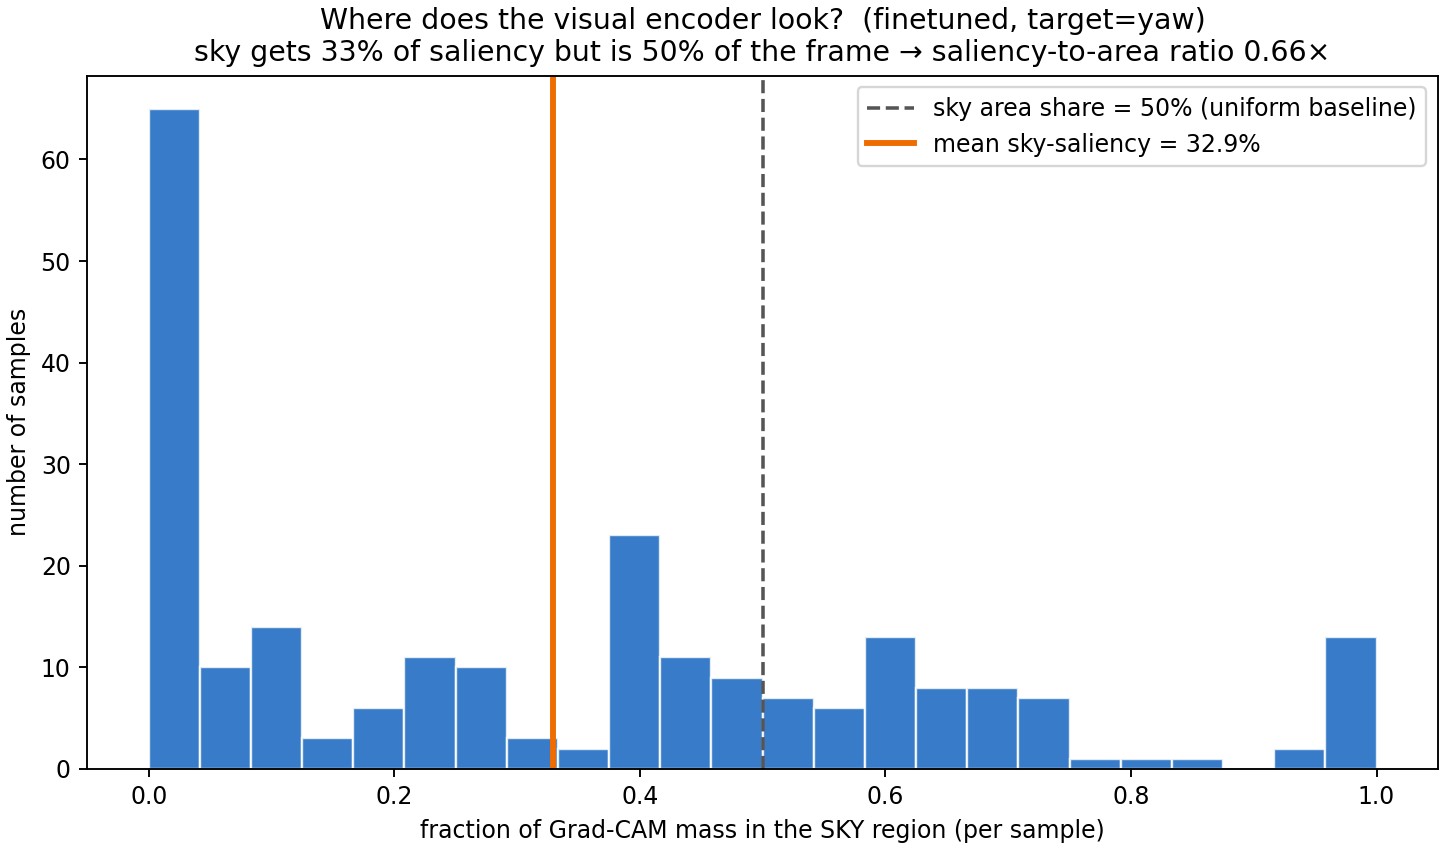

In [10]:
# side-by-side comparison of the headline numbers
import json
b=json.load(open('artifacts/quantify/sky_ground_baseline.json'))
f=json.load(open('artifacts/quantify/sky_ground_finetuned.json'))
eb=json.load(open(f'artifacts/evaluation/{EXP}/metrics.json'))['outputs'] if os.path.exists(f'artifacts/evaluation/{EXP}/metrics.json') else None
ef=json.load(open(f'artifacts/evaluation_rrr/{EXP}/metrics.json'))['outputs']
print('SKY saliency fraction:  baseline %.3f  ->  finetuned %.3f' % (b['sky_saliency_fraction_mean'], f['sky_saliency_fraction_mean']))
for k in ['next_body_dx','next_delta_yaw']:
    r_f=ef[k]['r2']
    print(f'{k}: finetuned R2={r_f:.3f}  MAE={ef[k]["mae"]:.5f}')
from IPython.display import Image, display
display(Image('artifacts/quantify/sky_ground_finetuned.png'))

In [11]:
# bundle results
import shutil
shutil.make_archive('/kaggle/working/vit_motion_interpret_plus','zip','artifacts')
print('Download vit_motion_interpret_plus.zip from the Output tab.')

Download vit_motion_interpret_plus.zip from the Output tab.
